# OSM Road Network Evolution — Annual Snapshots (2019–2024)

Run from the `notebooks/` directory, or open from repo root via Jupyter Lab/Notebook.

**Prerequisites:** Run the pipeline script from the repo root before opening this notebook:

```bash
python src/4_osm_clip_and_aggregate.py
```

**Input** (generated by the script above):

- `../data/outputs/osm_roads_by_class_year.csv`

**Data source:** OSM annual snapshots manually downloaded from [Geofabrik](https://download.geofabrik.de/south-america/colombia.html).  
Road class field: `fclass` — more granular than Overture's `class` (includes `track_grade1`…`track_grade5`, `*_link` variants, etc.)

## 0. Setup & data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

ROADS_PATH = "../data/outputs/osm_roads_by_class_year.csv"

df = pd.read_csv(ROADS_PATH)
df["mpio_id"] = df["mpio_id"].astype(str).str.zfill(5)
df["total_length_km"] = df["total_length_m"] / 1000

years = sorted(df["year"].unique())
zone_types = ["cabecera", "centro_poblado", "rural"]

ZONE_COLORS = {
    "cabecera": "#4C72B0",
    "centro_poblado": "#55A868",
    "rural": "#C44E52",
}

print(f"Rows       : {len(df):,}")
print(f"Years      : {years}")
print(f"fclass     : {df['fclass'].nunique()} distinct values")
print(f"Municipios : {df['mpio_id'].nunique()}")
df.head()

Rows       : 88,158
Years      : [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
fclass     : 27 distinct values
Municipios : 698


,mpio_id,municipio,departamento,zone_type,fclass,year,total_length_m,total_length_km
0,05002,ABEJORRAL,ANTIOQUIA,cabecera,bridleway,2019,755.206584,0.755207
1,05002,ABEJORRAL,ANTIOQUIA,cabecera,path,2019,290.762575,0.290763
2,05002,ABEJORRAL,ANTIOQUIA,cabecera,pedestrian,2019,560.265721,0.560266
3,05002,ABEJORRAL,ANTIOQUIA,cabecera,residential,2019,13517.606040,13.517606
4,05002,ABEJORRAL,ANTIOQUIA,cabecera,secondary,2019,2028.129660,2.028130


## 1. National total by year (sanity check)

Total road length (km) across all 698 selected municipalities, all zone types, all fclass values.  
Monotonically increasing network reflects OSM data growth (edits + new mapping).

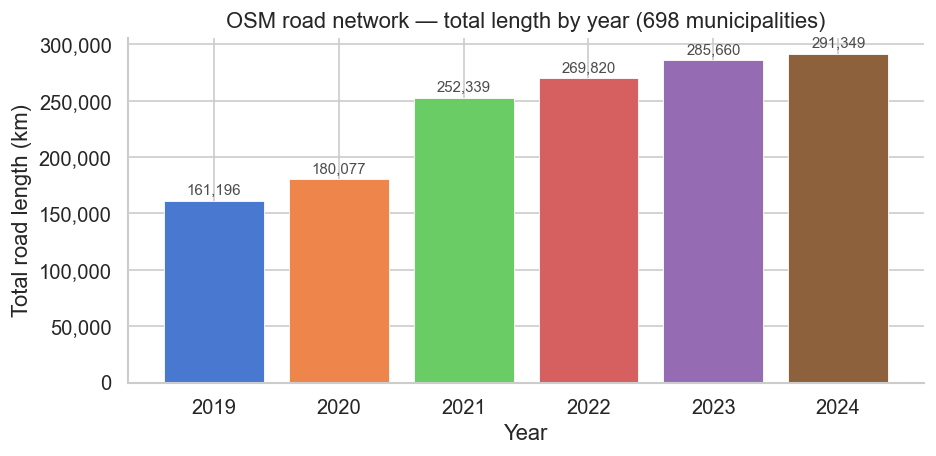

 year  total_length_km       yoy_km   yoy_pct
 2019    161195.731277          NaN       NaN
 2020    180076.954796 18881.223519 11.713228
 2021    252338.587831 72261.633035 40.128196
 2022    269819.780132 17481.192301  6.927673
 2023    285660.305438 15840.525306  5.870780
 2024    291349.443817  5689.138380  1.991575


In [2]:
national = df.groupby("year")["total_length_km"].sum().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    national["year"],
    national["total_length_km"],
    color=sns.color_palette("muted", len(years)),
    edgecolor="white",
    linewidth=0.5,
)

for _, row in national.iterrows():
    ax.text(
        row["year"],
        row["total_length_km"] + national["total_length_km"].max() * 0.01,
        f"{row['total_length_km']:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="0.3",
    )

ax.set_xlabel("Year")
ax.set_ylabel("Total road length (km)")
ax.set_title("OSM road network — total length by year (698 municipalities)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()

# YoY growth
national["yoy_km"] = national["total_length_km"].diff()
national["yoy_pct"] = national["total_length_km"].pct_change() * 100
print(national.to_string(index=False))

## 2. Total by year × zone type

Does OSM mapping growth concentrate in urban (`cabecera`) or rural areas?

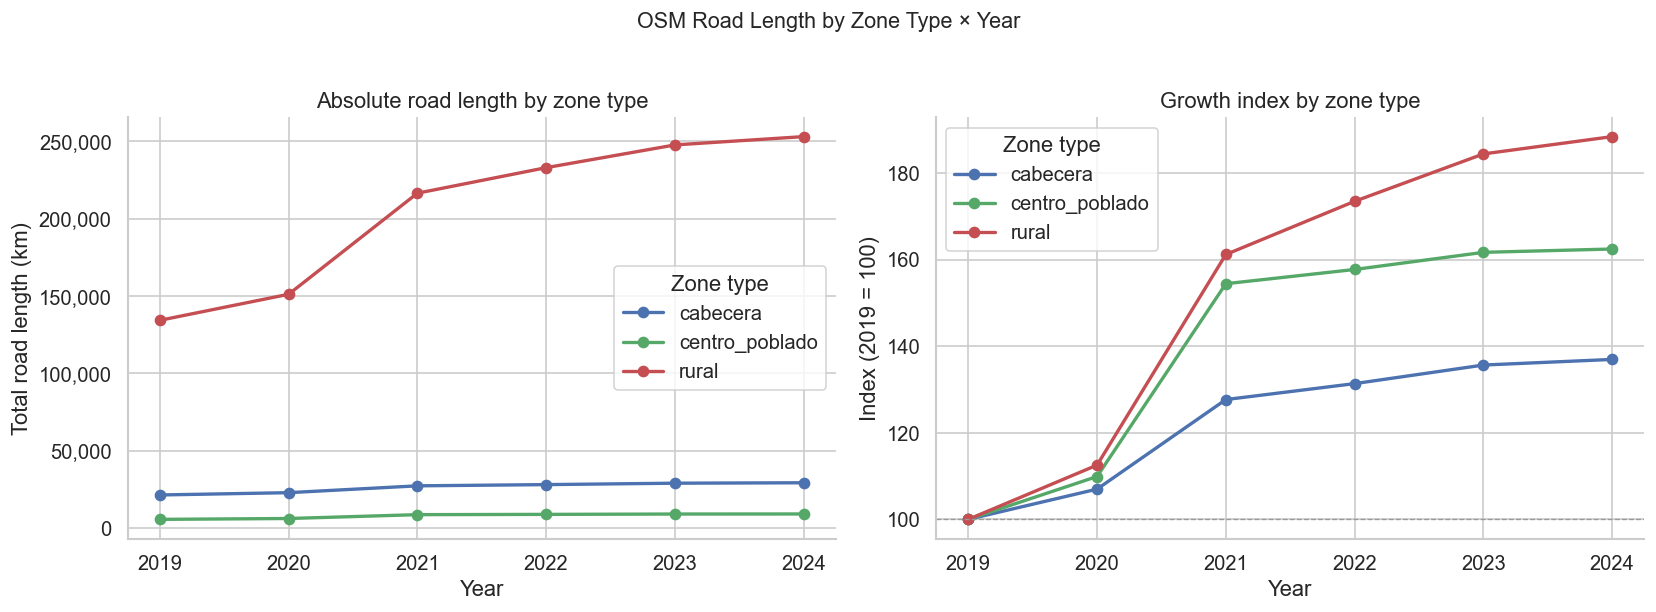

In [3]:
by_zone_year = (
    df.groupby(["year", "zone_type"])["total_length_km"]
    .sum()
    .unstack("zone_type")
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute lengths
ax = axes[0]
for zt in zone_types:
    if zt in by_zone_year.columns:
        ax.plot(
            by_zone_year.index,
            by_zone_year[zt],
            marker="o",
            label=zt,
            color=ZONE_COLORS[zt],
            linewidth=2,
        )
ax.set_xlabel("Year")
ax.set_ylabel("Total road length (km)")
ax.set_title("Absolute road length by zone type")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Zone type")
sns.despine(ax=ax)

# Growth index (first year = 100)
ax = axes[1]
idx = by_zone_year / by_zone_year.iloc[0] * 100
for zt in zone_types:
    if zt in idx.columns:
        ax.plot(
            idx.index, idx[zt], marker="o", label=zt, color=ZONE_COLORS[zt], linewidth=2
        )
ax.axhline(100, color="0.6", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel(f"Index ({years[0]} = 100)")
ax.set_title("Growth index by zone type")
ax.legend(title="Zone type")
sns.despine(ax=ax)

plt.suptitle("OSM Road Length by Zone Type × Year", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. fclass share by year — stacked 100% bar (all zone types)

Has the composition of road types in OSM shifted over time?  
Showing the top 10 fclass values by total length across all years.

Top fclass by total length: ['unclassified', 'residential', 'track', 'tertiary', 'secondary', 'service', 'path', 'track_grade3', 'trunk', 'primary']


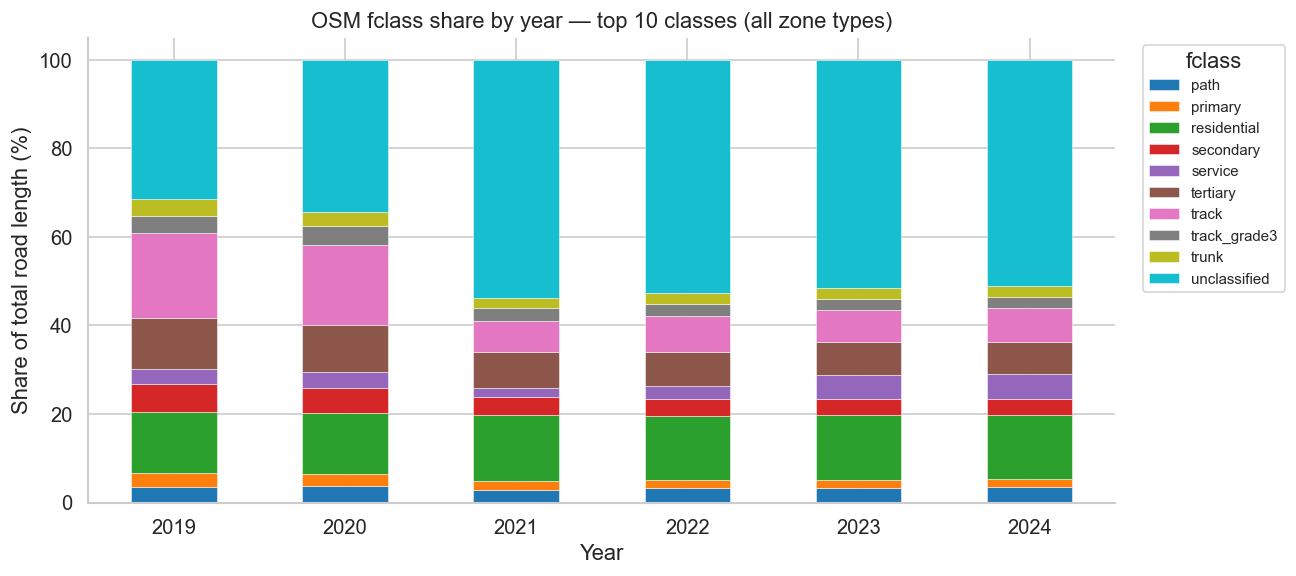

In [4]:
TOP_N = 10
top_classes = (
    df.groupby("fclass")["total_length_km"].sum().nlargest(TOP_N).index.tolist()
)
print("Top fclass by total length:", top_classes)

pivot = (
    df[df["fclass"].isin(top_classes)]
    .groupby(["year", "fclass"])["total_length_km"]
    .sum()
    .unstack("fclass")
    .fillna(0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
pivot_pct.plot(
    kind="bar", stacked=True, ax=ax, colormap="tab10", edgecolor="white", linewidth=0.3
)
ax.set_xlabel("Year")
ax.set_ylabel("Share of total road length (%)")
ax.set_title(f"OSM fclass share by year — top {TOP_N} classes (all zone types)")
ax.legend(title="fclass", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.tick_params(axis="x", rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

## 4. fclass share by zone type × year

Same as above but split into three subplots — one per zone type.  
Highlights whether the composition shift differs between urban and rural areas.

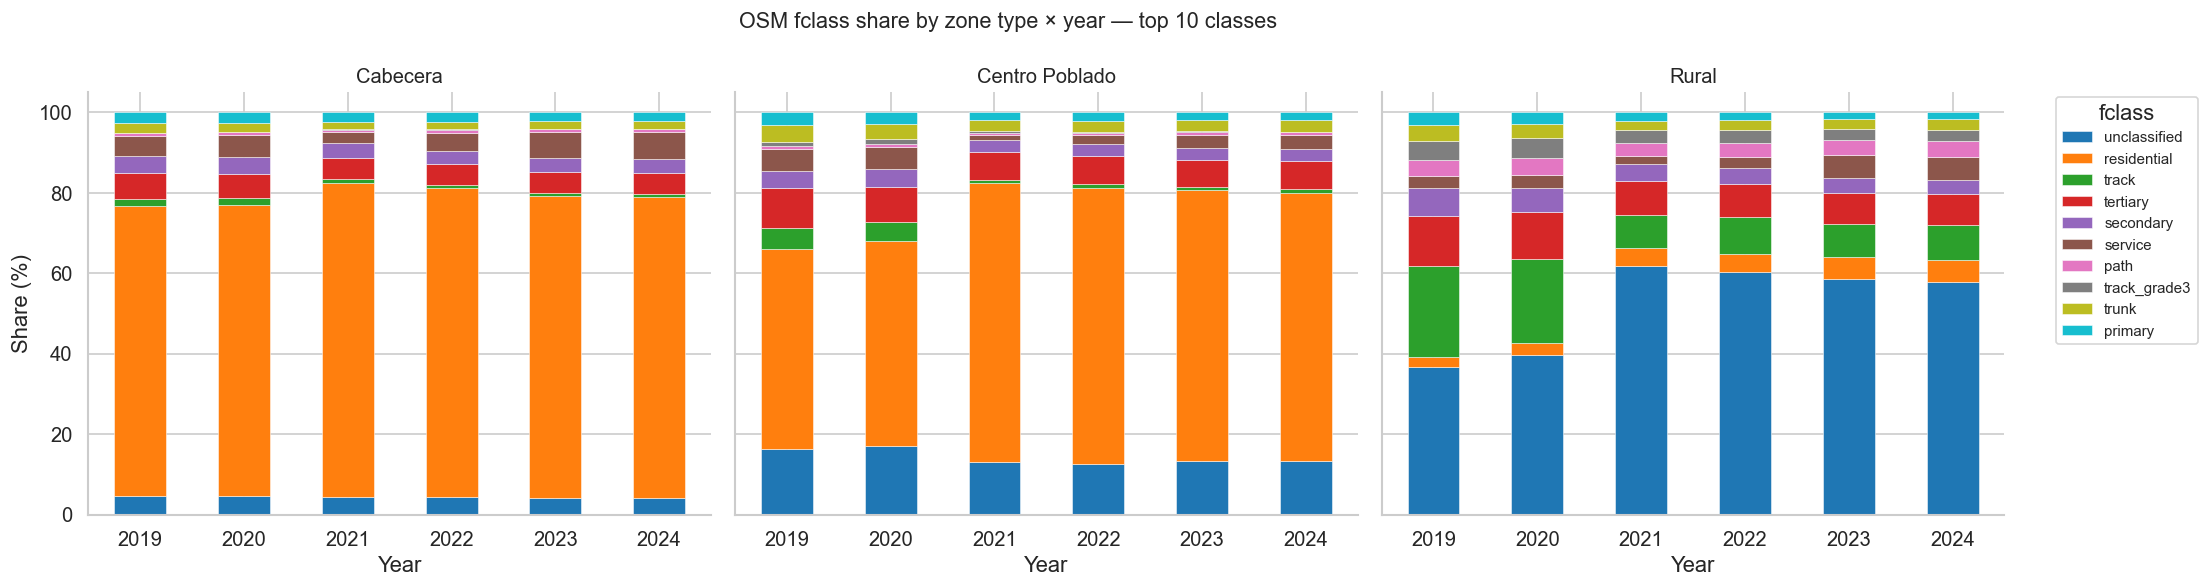

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, zt in zip(axes, zone_types):
    sub = df[(df["zone_type"] == zt) & (df["fclass"].isin(top_classes))]
    pivot_zt = (
        sub.groupby(["year", "fclass"])["total_length_km"]
        .sum()
        .unstack("fclass")
        .reindex(columns=top_classes)
        .fillna(0)
    )
    pivot_zt_pct = pivot_zt.div(pivot_zt.sum(axis=1), axis=0) * 100
    pivot_zt_pct.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        colormap="tab10",
        edgecolor="white",
        linewidth=0.3,
        legend=False,
    )
    ax.set_title(zt.replace("_", " ").title(), fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Share (%)" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=0)
    sns.despine(ax=ax)

fig.suptitle(f"OSM fclass share by zone type × year — top {TOP_N} classes", fontsize=13)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="fclass",
    bbox_to_anchor=(1.01, 0.85),
    loc="upper left",
    fontsize=9,
)
plt.tight_layout()
plt.show()

## 5. Year-over-year absolute change in road length per fclass

Which classes are growing and which are shrinking (or being reclassified)?  
Note: apparent shrinkage may reflect OSM reclassification, not actual road removal.

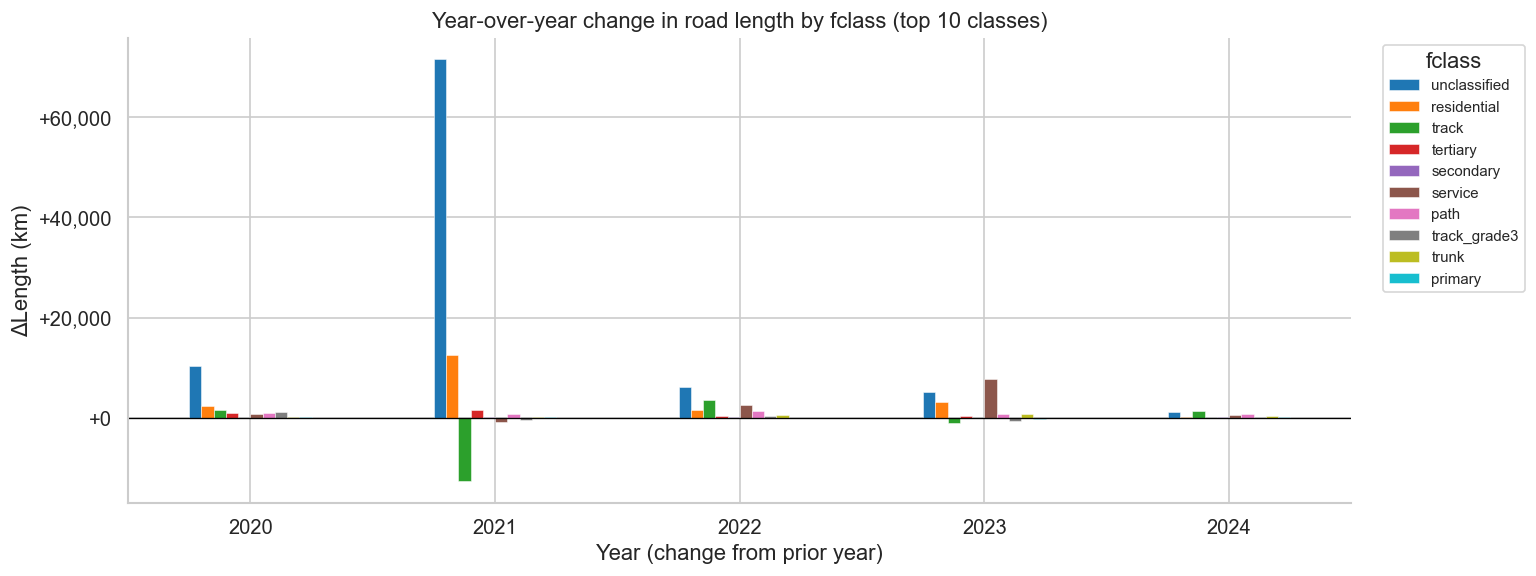


Year-over-year change (km):
fclass  unclassified  residential    track  tertiary  secondary  service    path  track_grade3  trunk  primary
year                                                                                                          
2020         10302.0       2321.7   1473.3     875.2       37.6    759.8   913.1        1193.9  107.7    127.2
2021         71653.1      12551.2 -12697.3    1514.3      191.0   -899.8   794.2        -519.3  198.0    150.2
2022          6197.7       1494.5   3484.5     325.6      150.7   2561.5  1380.9         425.9  547.3    -49.5
2023          5102.7       3069.8  -1020.0     353.6     -110.4   7822.5   800.1        -583.7  665.6   -319.9
2024          1063.7         85.4   1406.1      47.0      109.2    561.7   800.8         123.0  357.3    238.2


In [6]:
base_pivot = (
    df[df["fclass"].isin(top_classes)]
    .groupby(["year", "fclass"])["total_length_km"]
    .sum()
    .unstack("fclass")
    .reindex(columns=top_classes)
    .fillna(0)
)
yoy = base_pivot.diff().dropna()

fig, ax = plt.subplots(figsize=(13, 5))
yoy.plot(kind="bar", ax=ax, colormap="tab10", edgecolor="white", linewidth=0.3)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Year (change from prior year)")
ax.set_ylabel("ΔLength (km)")
ax.set_title("Year-over-year change in road length by fclass (top 10 classes)")
ax.legend(title="fclass", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+,.0f}"))
ax.tick_params(axis="x", rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

print("\nYear-over-year change (km):")
print(yoy.round(1).to_string())

## 6. Growth index per fclass (first year = 100)

Normalises each class to its length in the first available year (2019), making relative growth rates comparable across classes of very different absolute sizes.

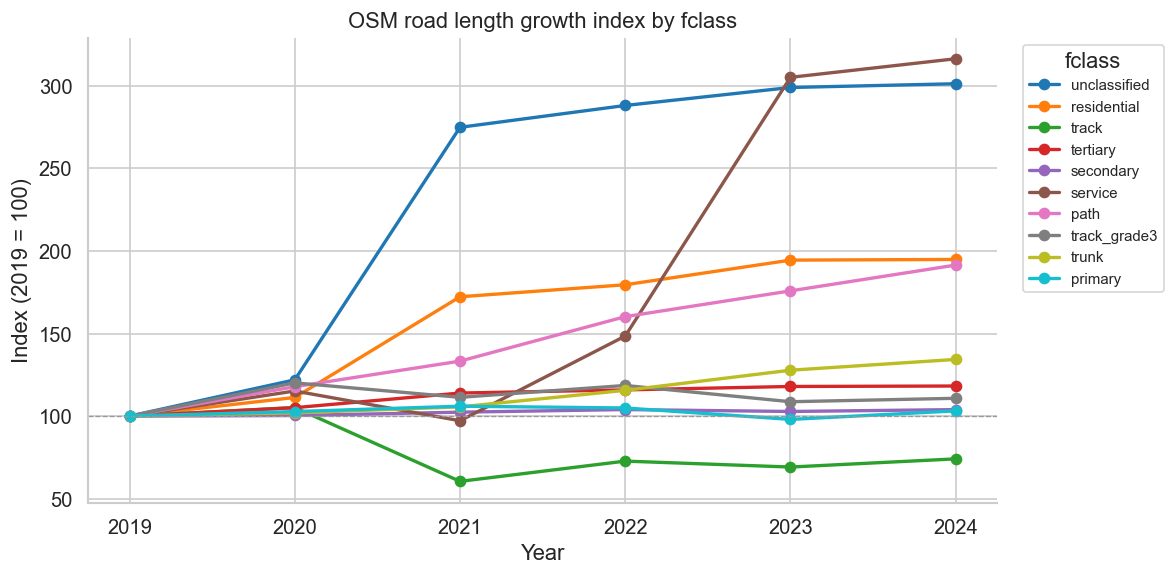

In [7]:
index = base_pivot / base_pivot.iloc[0] * 100

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette("tab10", len(top_classes))
for col, color in zip(index.columns, palette):
    ax.plot(index.index, index[col], marker="o", label=col, color=color, linewidth=2)

ax.axhline(100, color="0.6", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel(f"Index ({years[0]} = 100)")
ax.set_title("OSM road length growth index by fclass")
ax.legend(title="fclass", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()

## 7. YoY change by zone type × fclass (heatmap)

Rows = fclass, columns = year transition, panels = zone type.  
Colour intensity shows absolute km added/removed per transition.

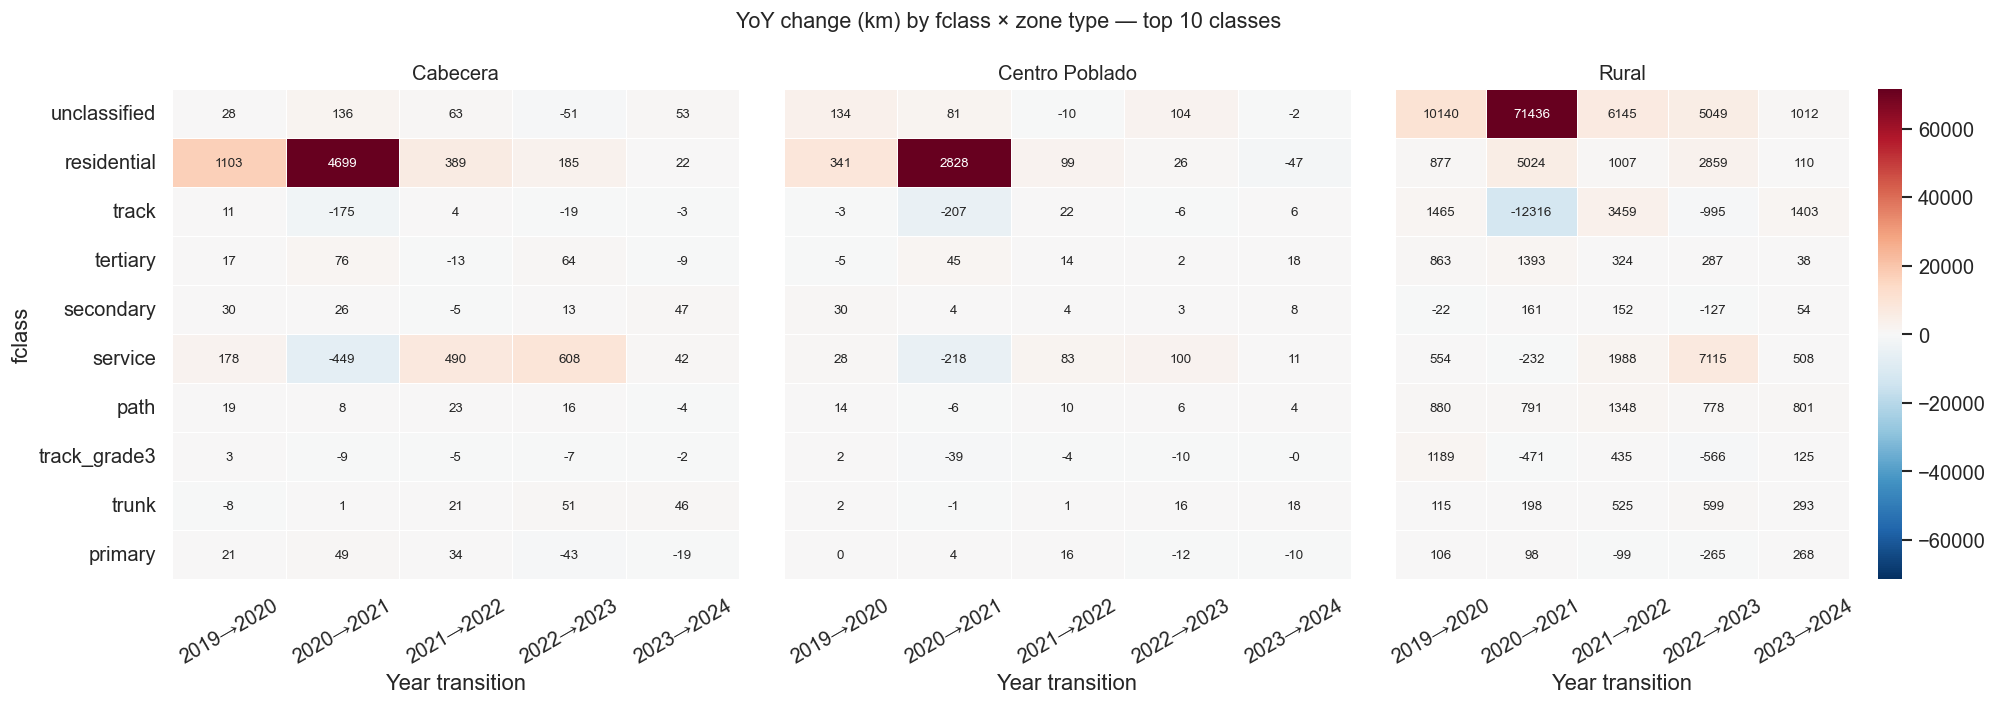

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True)

for ax, zt in zip(axes, zone_types):
    sub = df[(df["zone_type"] == zt) & (df["fclass"].isin(top_classes))]
    piv = (
        sub.groupby(["year", "fclass"])["total_length_km"]
        .sum()
        .unstack("fclass")
        .reindex(columns=top_classes)
        .fillna(0)
    )
    yoy_zt = piv.diff().dropna().T  # fclass as rows, year transitions as columns
    yoy_zt.columns = [f"{y - 1}→{y}" for y in yoy_zt.columns]

    vmax = yoy_zt.abs().max().max()
    sns.heatmap(
        yoy_zt,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        annot=True,
        fmt=".0f",
        annot_kws={"size": 8},
        linewidths=0.4,
        cbar=(ax == axes[-1]),
    )
    ax.set_title(zt.replace("_", " ").title(), fontsize=12)
    ax.set_xlabel("Year transition")
    ax.set_ylabel("fclass" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("YoY change (km) by fclass × zone type — top 10 classes", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Track family deep-dive

OSM distinguishes six track types: ungraded `track` plus `track_grade1` (best surface) through `track_grade5` (worst). Together these form the dominant rural road category in Colombia. This section unpacks their evolution.

**Grade guide (OSM convention):**

| Grade | Surface condition |
|---|---|
| 1 | Paved or very firm (passable by standard car) |
| 2 | Gravel / compacted earth (passable by car in dry season) |
| 3 | Rough earth (4WD recommended) |
| 4 | Very rough (high-clearance 4WD) |
| 5 | Impassable except by specialist vehicle |
| *(ungraded)* | Grade not yet assigned by OSM editors |

In [ ]:
TRACK_CLASSES = [
    "track",
    "track_grade1",
    "track_grade2",
    "track_grade3",
    "track_grade4",
    "track_grade5",
]
TRACK_LABELS = [
    "track\n(ungraded)",
    "grade 1\n(best)",
    "grade 2",
    "grade 3",
    "grade 4",
    "grade 5\n(worst)",
]
TRACK_COLORS = sns.color_palette("YlOrRd", len(TRACK_CLASSES))

track_df = df[df["fclass"].isin(TRACK_CLASSES)].copy()

# Summary table: km per grade per year
track_pivot = (
    track_df.groupby(["year", "fclass"])["total_length_km"]
    .sum()
    .unstack("fclass")
    .reindex(columns=TRACK_CLASSES)
    .fillna(0)
)
track_pivot["total_track_km"] = track_pivot.sum(axis=1)

# Share of total network that is any track
all_network = df.groupby("year")["total_length_km"].sum()
track_pivot["track_share_pct"] = track_pivot["total_track_km"] / all_network * 100

print("Track family — km by grade and year:")
print(track_pivot.round(0).to_string())

Track family — km by grade and year:
fclass    track  track_grade1  track_grade2  track_grade3  track_grade4  track_grade5  total_track_km  track_share_pct
year                                                                                                                  
2019    28405.0        1658.0        1594.0        5927.0        2323.0        1152.0         41060.0             25.0
2020    29878.0        1547.0        1552.0        7121.0        2776.0        1289.0         44164.0             25.0
2021    17181.0         675.0         801.0        6602.0        3216.0        1753.0         30229.0             12.0
2022    20665.0         672.0         817.0        7028.0        3508.0        1880.0         34570.0             13.0
2023    19646.0         592.0         672.0        6444.0        3532.0        1856.0         32742.0             11.0
2024    21052.0         588.0         651.0        6567.0        3628.0        1889.0         34375.0             12.0


### 8.1 Track total vs. network share by year

How much of the mapped network are tracks, and is that share stable?

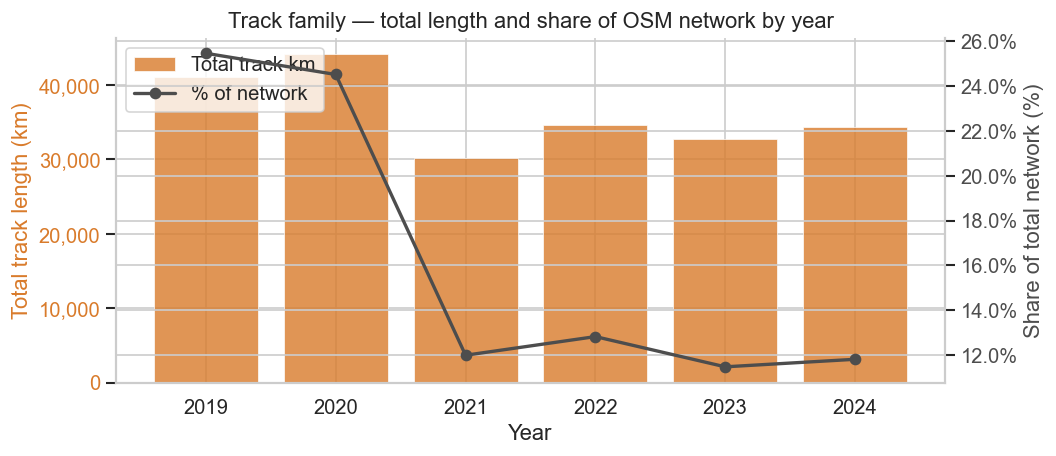

In [ ]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.bar(
    track_pivot.index,
    track_pivot["total_track_km"],
    color="#d97b2b",
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5,
    label="Total track km",
)
ax2.plot(
    track_pivot.index,
    track_pivot["track_share_pct"],
    marker="o",
    color="0.3",
    linewidth=2,
    label="% of network",
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Total track length (km)", color="#d97b2b")
ax1.tick_params(axis="y", labelcolor="#d97b2b")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax2.set_ylabel("Share of total network (%)", color="0.3")
ax2.tick_params(axis="y", labelcolor="0.3")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

ax1.set_title("Track family — total length and share of OSM network by year")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
sns.despine(right=False)
plt.tight_layout()
plt.show()

### 8.2 Grade breakdown — absolute and percentage by year

Stacked bars showing how the track family is distributed across grades each year.  
The large drop in ungraded `track` between 2020 and 2021 (with a simultaneous rise in graded sub-types) reflects OSM editors reclassifying previously ungraded tracks rather than new roads being built.

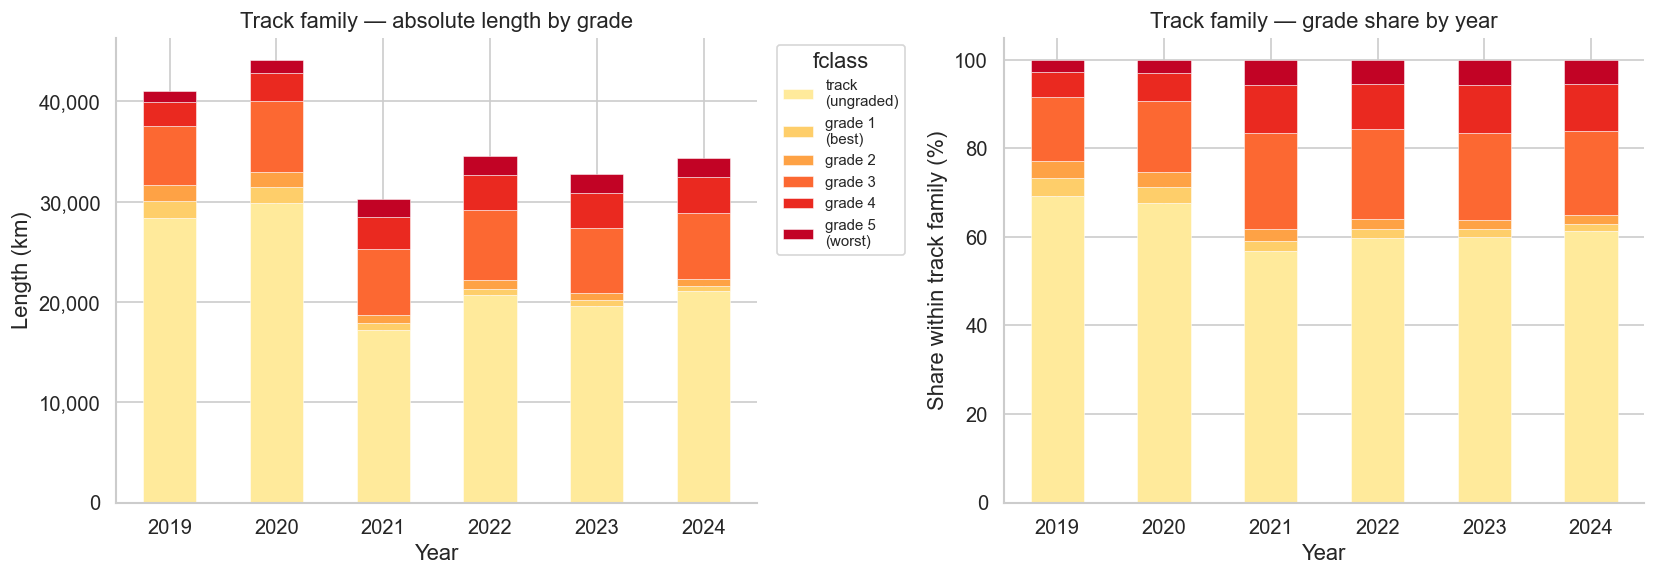

In [ ]:
grade_pivot = track_pivot[TRACK_CLASSES]
grade_pivot_pct = grade_pivot.div(grade_pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute
grade_pivot.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=TRACK_COLORS,
    edgecolor="white",
    linewidth=0.3,
)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Length (km)")
axes[0].set_title("Track family — absolute length by grade")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(
    TRACK_LABELS, title="fclass", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9
)
sns.despine(ax=axes[0])

# Percentage
grade_pivot_pct.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=TRACK_COLORS,
    edgecolor="white",
    linewidth=0.3,
)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Share within track family (%)")
axes[1].set_title("Track family — grade share by year")
axes[1].tick_params(axis="x", rotation=0)
axes[1].get_legend().remove()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

### 8.3 Grade breakdown by zone type

Do grading patterns differ between urban and rural zones? Rural areas are expected to concentrate the lower-quality grades.

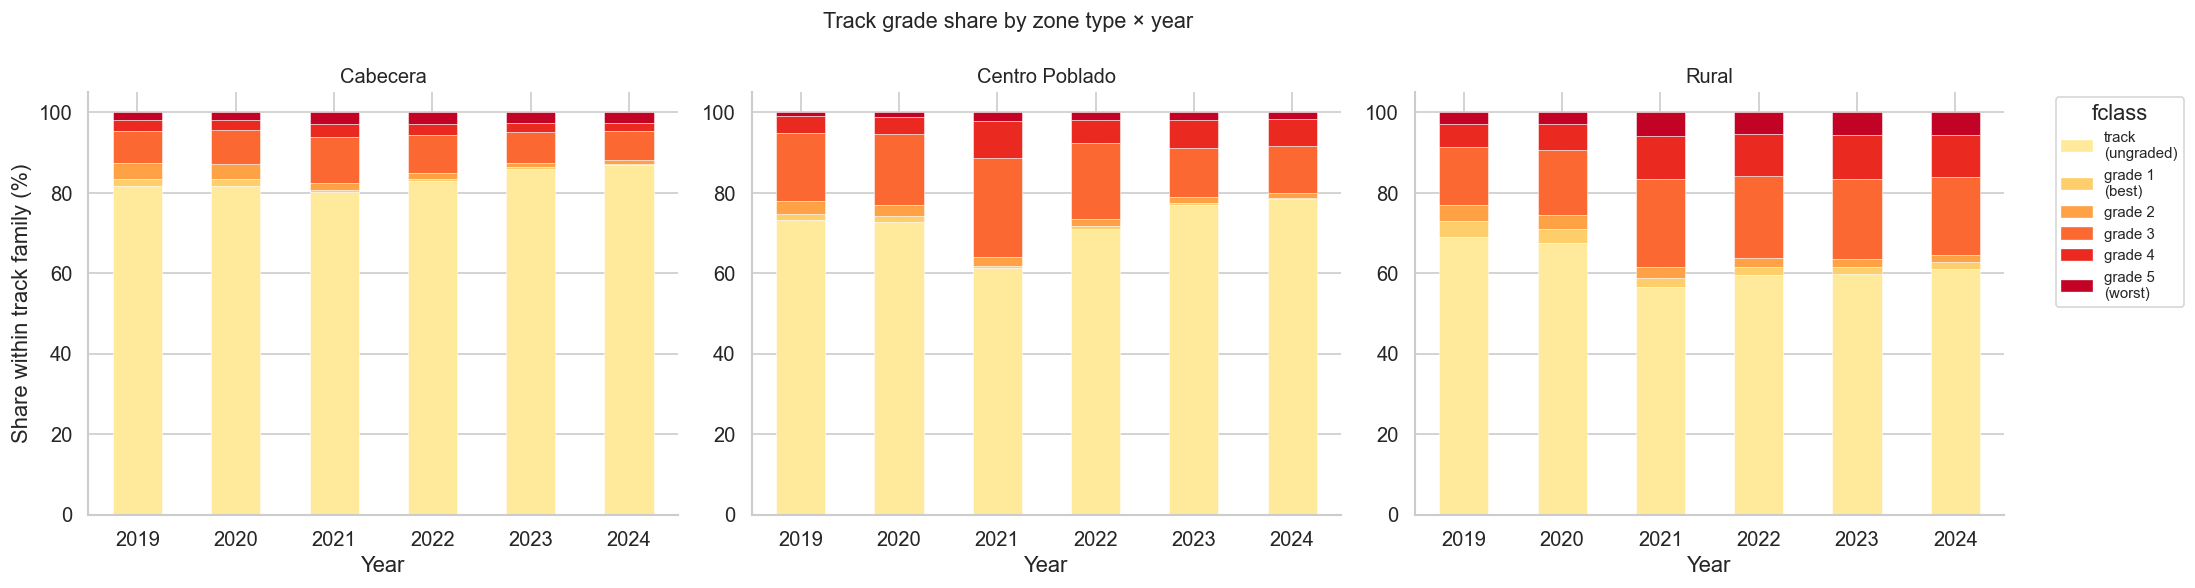

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)

for ax, zt in zip(axes, zone_types):
    sub = track_df[track_df["zone_type"] == zt]
    piv_zt = (
        sub.groupby(["year", "fclass"])["total_length_km"]
        .sum()
        .unstack("fclass")
        .reindex(columns=TRACK_CLASSES)
        .fillna(0)
    )
    piv_zt_pct = piv_zt.div(piv_zt.sum(axis=1), axis=0) * 100
    piv_zt_pct.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=TRACK_COLORS,
        edgecolor="white",
        linewidth=0.3,
        legend=False,
    )
    ax.set_title(zt.replace("_", " ").title(), fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Share within track family (%)" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=0)
    sns.despine(ax=ax)

fig.suptitle("Track grade share by zone type × year", fontsize=13)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in TRACK_COLORS]
fig.legend(
    handles,
    TRACK_LABELS,
    title="fclass",
    bbox_to_anchor=(1.01, 0.85),
    loc="upper left",
    fontsize=9,
)
plt.tight_layout()
plt.show()

### 8.4 Grade reclassification signal — YoY change per grade

Isolates the year-over-year km change for each grade. The 2020→2021 transition is the key event: ungraded `track` shed ~12,000 km while grades 3–5 absorbed most of that, a clear editing campaign rather than infrastructure change.

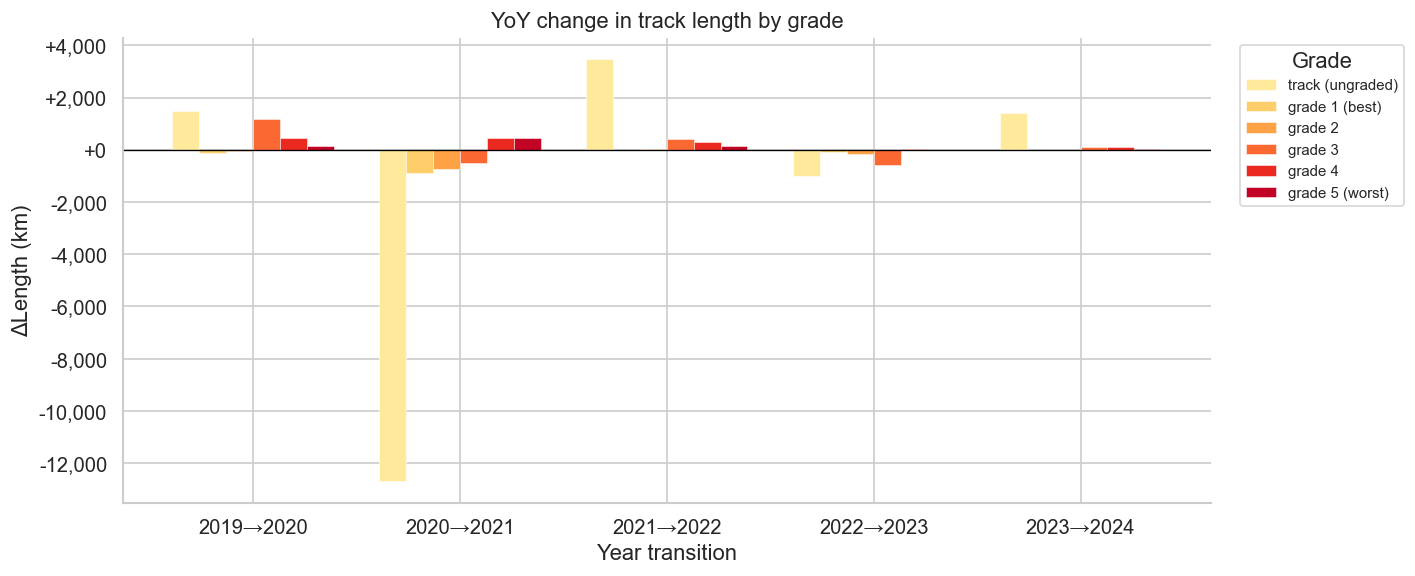


YoY change (km) by grade:
      track\n(ungraded)  grade 1\n(best)  grade 2  grade 3  grade 4  grade 5\n(worst)
year                                                                                 
2020             1473.0           -111.0    -42.0   1194.0    453.0             137.0
2021           -12697.0           -872.0   -751.0   -519.0    440.0             464.0
2022             3485.0             -3.0     15.0    426.0    291.0             127.0
2023            -1020.0            -80.0   -144.0   -584.0     24.0             -24.0
2024             1406.0             -4.0    -21.0    123.0     96.0              33.0


In [ ]:
yoy_track = grade_pivot.diff().dropna()
yoy_track.columns = TRACK_LABELS

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(yoy_track))
width = 0.13
for i, (col, color) in enumerate(zip(yoy_track.columns, TRACK_COLORS)):
    ax.bar(
        x + i * width,
        yoy_track[col],
        width=width,
        color=color,
        label=col.replace("\n", " "),
        edgecolor="white",
        linewidth=0.3,
    )

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x + width * (len(TRACK_CLASSES) - 1) / 2)
ax.set_xticklabels([f"{y - 1}→{y}" for y in yoy_track.index])
ax.set_xlabel("Year transition")
ax.set_ylabel("ΔLength (km)")
ax.set_title("YoY change in track length by grade")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+,.0f}"))
ax.legend(title="Grade", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

print("\nYoY change (km) by grade:")
print(yoy_track.round(0).to_string())